# Homework 2: Machine Learning for Regression
Esteban Martínez Camargo

## Dataset

In [5]:
import pandas as pd
import numpy as np

df_csv = pd.read_csv('car_fuel_efficiency_2026.csv')
df = df_csv[[
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg']]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## EDA
Look at the fuel_efficiency_mpg variable. Does it have a long tail?

Summary statistics:
count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64
Skewness: 0.081


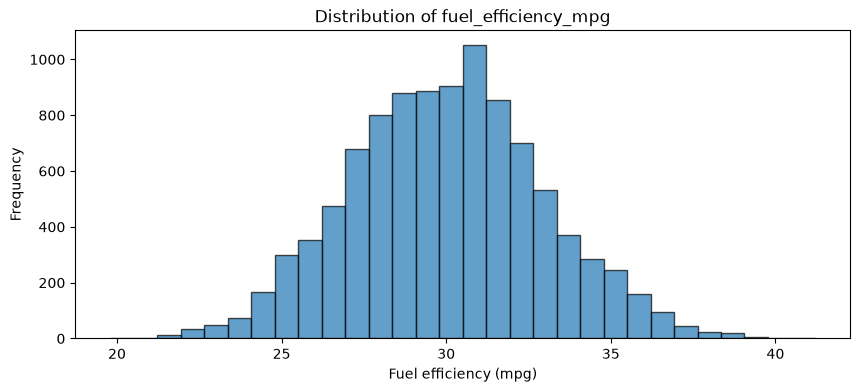

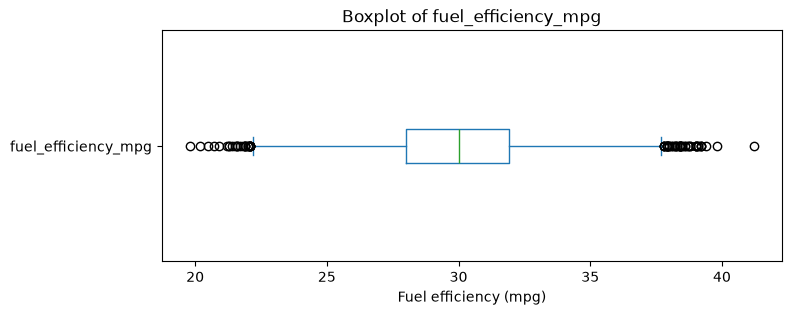

In [6]:
import matplotlib.pyplot as plt

s = df['fuel_efficiency_mpg']

print("Summary statistics:")
print(s.describe())
print(f"Skewness: {s.skew():.3f}")

# Histogram: a long tail usually shows up as a right-skewed distribution
plt.figure(figsize=(10, 4))
s.plot(kind='hist', bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of fuel_efficiency_mpg')
plt.xlabel('Fuel efficiency (mpg)')
plt.ylabel('Frequency')
plt.show()

# Boxplot helps visualize tail and outliers
plt.figure(figsize=(8, 3))
s.plot(kind='box', vert=False)
plt.title('Boxplot of fuel_efficiency_mpg')
plt.xlabel('Fuel efficiency (mpg)')
plt.show()

# Question 1

There's one column with missing values. What is it?

In [8]:
missing_values = df.columns[df.isna().any()].tolist()
print(f"Columns with missing values: {missing_values}")

Columns with missing values: ['horsepower']


# Question 2

What's the median (50% percentile) for variable 'horsepower'?

In [9]:
median_horsepower = df['horsepower'].median()
print(f"Median horsepower: {median_horsepower}")

Median horsepower: 254.0


## Prepare and split the dataset

Shuffle the filtered dataset and create the split exactly as in the lecture:

In [10]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

# Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
* Which option gives better RMSE?

In [11]:
features = [col for col in df.columns if col != 'fuel_efficiency_mpg']
target = 'fuel_efficiency_mpg'

y_train = df_train[target].to_numpy()
y_val = df_val[target].to_numpy()

def train_linear_regression(X, y):
    X = np.column_stack([np.ones(len(X)), X])
    return np.linalg.solve(X.T @ X, X.T @ y)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# Impute missing horsepower with 0
X_train_zero = df_train[features].fillna(0).to_numpy()
X_val_zero = df_val[features].fillna(0).to_numpy()
w_zero = train_linear_regression(X_train_zero, y_train)
score_zero = round(rmse(y_val, np.column_stack([np.ones(len(X_val_zero)), X_val_zero]) @ w_zero), 3)

# Impute using the training-set mean
horsepower_mean = df_train['horsepower'].mean()
X_train_mean = df_train[features].fillna(horsepower_mean).to_numpy()
X_val_mean = df_val[features].fillna(horsepower_mean).to_numpy()
w_mean = train_linear_regression(X_train_mean, y_train)
score_mean = round(rmse(y_val, np.column_stack([np.ones(len(X_val_mean)), X_val_mean]) @ w_mean), 3)

print(f"RMSE with 0 imputation: {score_zero}")
print(f"RMSE with mean imputation: {score_mean}")
print("Better option:", "mean" if score_mean < score_zero else "0" if score_zero < score_mean else "tie")

RMSE with 0 imputation: 2.205
RMSE with mean imputation: 2.202
Better option: mean


# Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0.
* Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
* Which r gives the best RMSE?

If multiple options give the same best RMSE, select the smallest r.

In [15]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

X_train = np.column_stack([np.ones(len(X_train_zero)), X_train_zero])
X_val = np.column_stack([np.ones(len(X_val_zero)), X_val_zero])
penalty = np.eye(X_train.shape[1])
penalty[0, 0] = 0  # Do not regularize the intercept

rmse_scores = {}

for r in r_values:
    w = np.linalg.solve(X_train.T @ X_train + r * penalty, X_train.T @ y_train)
    rmse_scores[r] = round(rmse(y_val, X_val @ w), 10)
    print(f"r={r}: RMSE={rmse_scores[r]}")

best_r = min(r_values, key=lambda r: (rmse_scores[r], r))
print(f"Best r: {best_r}")

r=0: RMSE=2.2052931948
r=0.01: RMSE=2.2052931948
r=0.1: RMSE=2.2052931952
r=1: RMSE=2.2052931993
r=5: RMSE=2.2052932176
r=10: RMSE=2.2052932404
r=100: RMSE=2.2052936541
Best r: 0


# Question 5

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
* What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
* Round the result to 3 decimal digits (round(std, 3))

What's the value of std?

In [16]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
scores = []

for seed in seeds:
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    y_train = df_train[target].to_numpy()
    y_val = df_val[target].to_numpy()

    X_train = df_train[features].fillna(0).to_numpy()
    X_val = df_val[features].fillna(0).to_numpy()

    X_train_aug = np.column_stack([np.ones(len(X_train)), X_train])
    X_val_aug = np.column_stack([np.ones(len(X_val)), X_val])

    w = np.linalg.solve(X_train_aug.T @ X_train_aug, X_train_aug.T @ y_train)
    pred = X_val_aug @ w
    rmse = np.sqrt(np.mean((y_val - pred) ** 2))
    scores.append(rmse)

std = round(np.std(scores), 3)
print(f"RMSE scores by seed: {scores}")
print(f"std = {std}")

RMSE scores by seed: [np.float64(2.239204143050831), np.float64(2.2021128210837757), np.float64(2.1634197787531178), np.float64(2.2043588768529823), np.float64(2.201880094331822), np.float64(2.245785150908247), np.float64(2.269721207951651), np.float64(2.1907945999354297), np.float64(2.2166112016944135), np.float64(2.207036592823297)]
std = 0.029


# Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with r=0.001.
* What's the RMSE on the test dataset?